# Thesis Results Evaluation

Reproduce the statistical analysis tables from the MSc thesis.  
Extracts **throughput**, **waiting**, and **processing** time metrics from simulation eval logs.

Supports:
- **Dataset mode**: Point to `results/cvs_pharmacy` (standard results)
- **Run mode**: Point to `results/runs/<name>` (orchestrator runs)
- **Eval type toggle**: `eval` (intermediate) vs `final_eval` (test set) logs
- **Training convergence**: Reward & volunteer rate curves per episode

## 1. Configuration

Set the dataset path and which methods + eval logs to use.

In [57]:
# ── EDIT THESE ──────────────────────────────────────────────────────────────

# ── MODE 1: Dataset (standard results) ──
# DATASET_DIR = "../../results/cvs_pharmacy"

# ── MODE 2: Orchestrator run (from run_experiment.py) ──
# Set RUN_NAME to select a run from results/runs/.
# Leave as None to use DATASET_DIR instead.
RUN_NAME = "regular_fixed_simple_reward"   # or None to use DATASET_DIR

# Fallback dataset dir (used when RUN_NAME is None)
DATASET_DIR = "../../results/runs"

# ── Common settings ─────────────────────────────────────────────────────────

# Which methods to include (None = auto-discover all)
METHODS = None

# Eval log type:
#   "final_eval" → final evaluation on TEST data (recommended for thesis)
#   "eval"       → intermediate evals on TRAIN data (for debugging/convergence)
#   "train"      → training episode logs
EVAL_TYPE = "train"   # "eval", "final_eval", or "train"

# Target RL method for pairwise statistical tests (None = auto-detect)
TARGET_METHOD = None

# Working-time filter: only count Mon-Fri 08:00-19:00 in duration metrics.
# Removes overnight/weekend "dead time" so method differences are visible.
# Set to False for datasets without weekday patterns (e.g. continuous).
USE_WORKING_TIME = True

# ────────────────────────────────────────────────────────────────────────────

## 2. Imports & Setup

In [58]:
import sys
import re
import importlib
import warnings
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

# Force reload to pick up any changes to evaluate_results.py
import evaluate_results
importlib.reload(evaluate_results)

# Import functions from the evaluation module
from evaluate_results import (
    METHOD_DISPLAY_NAMES, METHOD_ORDER,
    extract_case_metrics, extract_assignment_types, compute_volunteer_rate,
    find_latest_run, find_eval_logs,
    load_method_metrics, discover_methods, compute_descriptive_stats,
    ks_normality_test, kruskal_wallis_test, mann_whitney_u_test, cliffs_delta,
)

print("Imports OK")

Imports OK


## 3. Load Data

In [59]:
# Resolve dataset directory — handles both modes
if RUN_NAME:
    # Run mode: results/runs/<name>/
    run_dir = Path(f"../../results/runs/{RUN_NAME}")
    assert run_dir.exists(), f"Run not found: {run_dir.resolve()}"

    # Detect structure: flat (mappo_collab/, baseline_random/) or nested (cvs_pharmacy/mappo/collab/)
    skip = {"logs", "configs", ".tmp_configs"}
    subdirs = [
        d for d in run_dir.iterdir()
        if d.is_dir() and d.name not in skip and not d.name.startswith(".")
    ]

    # Flat structure: dirs start with mappo_ or baseline_
    has_flat = any(d.name.startswith(("mappo_", "baseline_")) for d in subdirs)

    if has_flat:
        # Flat mode: method dirs are directly in run_dir
        dataset_dir = run_dir
        print(f"Run: {run_dir.resolve()}")
        print(f"Structure: flat (mappo_*, baseline_*)")
    else:
        # Nested mode: find dataset subfolder (e.g. cvs_pharmacy/)
        dataset_candidates = [d for d in subdirs]
        assert dataset_candidates, f"No dataset folder found in {run_dir}"
        dataset_dir = dataset_candidates[0]
        print(f"Run: {run_dir.resolve()}")
        print(f"Dataset: {dataset_dir.name}")
else:
    # Standard dataset mode
    dataset_dir = Path(DATASET_DIR)

assert dataset_dir.exists(), f"Dataset dir not found: {dataset_dir.resolve()}"

# Discover available methods
discovered = discover_methods(dataset_dir)
print(f"Dataset path: {dataset_dir.resolve()}")
print(f"Available methods: {list(discovered.keys())}")

# Filter if METHODS is set
if METHODS:
    discovered = {k: v for k, v in discovered.items() if k in METHODS}
    print(f"Selected methods: {list(discovered.keys())}")

# Show run directories
print(f"\nRun directories:")
for method_name, run_path in discovered.items():
    display_name = METHOD_DISPLAY_NAMES.get(method_name, method_name)
    print(f"  {display_name:<25} {run_path}")

Run: /Users/bjornkoemans/Documents/GitHub/master-cope/results/runs/regular_fixed_simple_reward
Structure: flat (mappo_*, baseline_*)
Dataset path: /Users/bjornkoemans/Documents/GitHub/master-cope/results/runs/regular_fixed_simple_reward
Available methods: ['baseline_random_collab', 'mappo_collab_comm']

Run directories:
  Random (collab)           ../../results/runs/regular_fixed_simple_reward/baseline_random_collab
  MAPPO+Collab+Comm         ../../results/runs/regular_fixed_simple_reward/mappo_collab_comm


In [60]:
# Determine eval pattern and mode based on EVAL_TYPE
if EVAL_TYPE == "final_eval":
    EVAL_PATTERN = "log_final_eval_*"
    USE_TRAIN = False
    log_label = "final_eval"
elif EVAL_TYPE == "eval":
    EVAL_PATTERN = "log_eval_*"
    USE_TRAIN = False
    log_label = "eval"
elif EVAL_TYPE == "train":
    EVAL_PATTERN = "log_train_*"
    USE_TRAIN = True
    log_label = "train"
else:
    raise ValueError(f"Unknown EVAL_TYPE: {EVAL_TYPE}. Use 'eval', 'final_eval', or 'train'.")

time_label = "working-time" if USE_WORKING_TIME else "wall-clock"
print(f"Log type: {log_label} (pattern: {EVAL_PATTERN})")
print(f"Time mode: {time_label}")
print()

# Load metrics from all selected methods
all_metrics = OrderedDict()

for method_name, run_dir in discovered.items():
    display_name = METHOD_DISPLAY_NAMES.get(method_name, method_name)
    metrics = load_method_metrics(
        run_dir, EVAL_PATTERN,
        use_train=USE_TRAIN,
        use_working_time=USE_WORKING_TIME,
    )
    all_metrics[method_name] = metrics

    if USE_TRAIN:
        train_dir = run_dir / "logs" / "train"
        if train_dir.exists():
            n_logs = len(sorted(train_dir.glob("log_train_*.csv")))
        else:
            n_logs = len(sorted((run_dir / "logs").glob("log_train_*.csv"))) if (run_dir / "logs").exists() else 0
    else:
        n_logs = len(find_eval_logs(run_dir, EVAL_PATTERN))
    n_cases = len(metrics["throughput"])
    vol_rate = metrics.get("volunteer_rate", 0.0)
    print(f"  {display_name:<25} {n_logs} {log_label} logs  {n_cases} cases  vol_rate={vol_rate:.1f}%")

Log type: final_eval (pattern: log_final_eval_*)
Time mode: working-time

  Random (collab)           10 final_eval logs  16760 cases  vol_rate=68.6%
  MAPPO+Collab+Comm         10 final_eval logs  16760 cases  vol_rate=51.1%


## 4. Descriptive Statistics Tables

These reproduce Tables 3, 4, and 5 from the thesis.

In [61]:
def build_stats_df(all_metrics, metric_key, metric_label):
    """Build a styled DataFrame for one metric, matching thesis table format."""
    rows = []
    
    # Order by thesis convention
    ordered_keys = []
    for display_name in METHOD_ORDER:
        for mk in all_metrics:
            if METHOD_DISPLAY_NAMES.get(mk, mk) == display_name:
                ordered_keys.append(mk)
                break
    # Add any remaining
    for mk in all_metrics:
        if mk not in ordered_keys:
            ordered_keys.append(mk)
    
    for mk in ordered_keys:
        dn = METHOD_DISPLAY_NAMES.get(mk, mk)
        stats = compute_descriptive_stats(all_metrics[mk][metric_key])
        rows.append({
            "Agent": dn,
            "Mean": stats["Mean"],
            "Median": stats["Median"],
            "Std. Dev.": stats["Std. Dev."],
            "Min.": stats["Min."],
            "Max.": stats["Max."],
            "N": int(stats["N"]),
        })
    
    df = pd.DataFrame(rows).set_index("Agent")
    df.index.name = None
    return df

In [62]:
print(f"Throughput time (case end − case open) in minutes [{time_label}]")
df_throughput = build_stats_df(all_metrics, "throughput", "Throughput")
df_throughput.round(2)

Throughput time (case end − case open) in minutes [working-time]


,Mean,Median,Std. Dev.,Min.,Max.,N
Random (collab),6505.46,7758.83,2718.09,9.50,10580.34,16760
MAPPO+Collab+Comm,6352.81,7601.91,2670.77,9.98,10515.62,16760


In [63]:
print(f"Total waiting time (first task start − case open) in minutes [{time_label}]")
df_waiting = build_stats_df(all_metrics, "waiting", "Waiting")
df_waiting.round(2)

Total waiting time (first task start − case open) in minutes [working-time]


,Mean,Median,Std. Dev.,Min.,Max.,N
Random (collab),914.65,963.19,532.01,0.0,1911.85,16760
MAPPO+Collab+Comm,891.63,960.39,515.75,0.0,1845.67,16760


In [64]:
print(f"Total processing time (sum of task durations) in minutes [{time_label}]")
df_processing = build_stats_df(all_metrics, "processing", "Processing")
df_processing.round(2)

Total processing time (sum of task durations) in minutes [working-time]


,Mean,Median,Std. Dev.,Min.,Max.,N
Random (collab),12.13,10.57,6.00,5.14,77.96,18080
MAPPO+Collab+Comm,12.01,10.58,5.46,4.18,76.67,18080


## 4b. Assignment Type Distribution & Volunteer Rate

Shows how tasks were assigned: **volunteer** (agents chose to take the task) vs **fallback** (random assignment because nobody volunteered).

In [65]:
# Build volunteer rate summary table
vol_rows = []
for mk in all_metrics:
    dn = METHOD_DISPLAY_NAMES.get(mk, mk)
    at = all_metrics[mk].get("assignment_types", {})
    vol_rate = all_metrics[mk].get("volunteer_rate", 0.0)
    volunteer_total = sum(v for k, v in at.items() if 'volunteer' in k.lower())
    fallback_total = sum(v for k, v in at.items() if 'fallback' in k.lower())
    total = sum(at.values())
    vol_rows.append({
        "Agent": dn,
        "Volunteer Rate (%)": round(vol_rate, 1),
        "Volunteer Tasks": volunteer_total,
        "Fallback Tasks": fallback_total,
        "Total Tasks": total,
    })

df_vol = pd.DataFrame(vol_rows).set_index("Agent")
df_vol.index.name = None
print("Volunteer rate per method")
df_vol

Volunteer rate per method


,Volunteer Rate (%),Volunteer Tasks,Fallback Tasks,Total Tasks
Random (collab),68.6,102948,47202,150150
MAPPO+Collab+Comm,51.1,76690,73460,150150


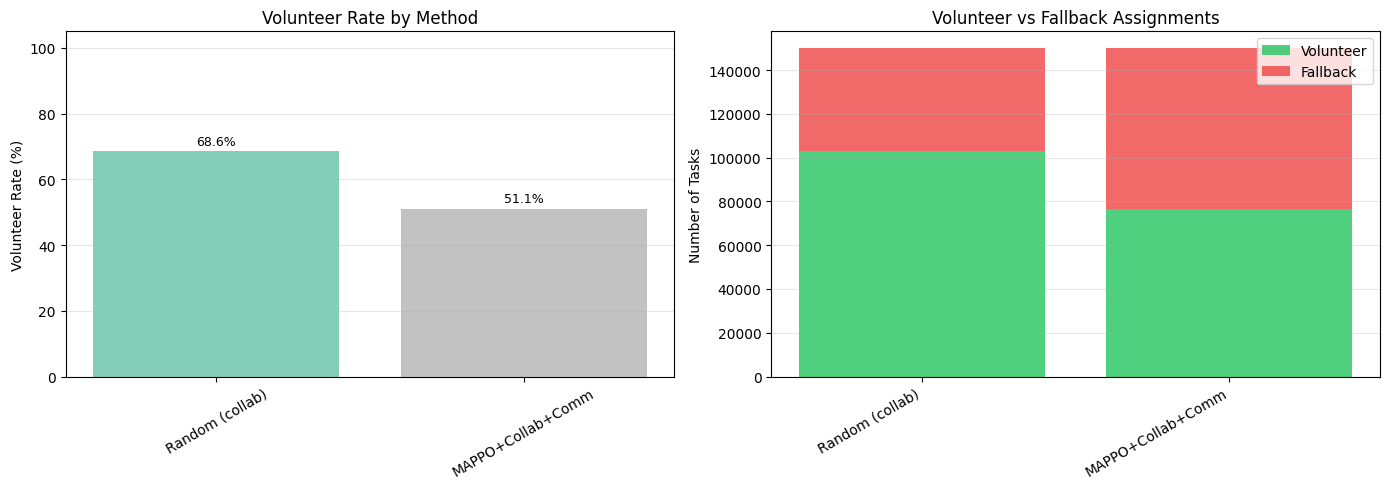

In [66]:
# Volunteer rate bar chart
import matplotlib.pyplot as plt

ordered_keys_v = []
ordered_names_v = []
for display_name in METHOD_ORDER:
    for mk in all_metrics:
        if METHOD_DISPLAY_NAMES.get(mk, mk) == display_name:
            ordered_keys_v.append(mk)
            ordered_names_v.append(display_name)
            break
for mk in all_metrics:
    if mk not in ordered_keys_v:
        ordered_keys_v.append(mk)
        ordered_names_v.append(METHOD_DISPLAY_NAMES.get(mk, mk))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Volunteer rate bar chart
vol_rates = [all_metrics[mk].get("volunteer_rate", 0.0) for mk in ordered_keys_v]
colors = plt.cm.Set2(np.linspace(0, 1, len(ordered_names_v)))
bars = ax1.bar(ordered_names_v, vol_rates, color=colors, alpha=0.8)
ax1.set_ylabel("Volunteer Rate (%)")
ax1.set_title("Volunteer Rate by Method")
ax1.set_ylim(0, 105)
ax1.grid(True, alpha=0.3, axis="y")
ax1.tick_params(axis="x", rotation=30)
for bar, rate in zip(bars, vol_rates):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{rate:.1f}%", ha="center", va="bottom", fontsize=9)

# Right: Stacked bar (volunteer vs fallback)
volunteer_counts = []
fallback_counts = []
for mk in ordered_keys_v:
    at = all_metrics[mk].get("assignment_types", {})
    volunteer_counts.append(sum(v for k, v in at.items() if 'volunteer' in k.lower()))
    fallback_counts.append(sum(v for k, v in at.items() if 'fallback' in k.lower()))

x = np.arange(len(ordered_names_v))
ax2.bar(x, volunteer_counts, label="Volunteer", color="#22c55e", alpha=0.8)
ax2.bar(x, fallback_counts, bottom=volunteer_counts, label="Fallback", color="#ef4444", alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(ordered_names_v, rotation=30, ha="right")
ax2.set_ylabel("Number of Tasks")
ax2.set_title("Volunteer vs Fallback Assignments")
ax2.legend()
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 5. Statistical Tests

### 5.1 Kolmogorov-Smirnov Normality Test

In [67]:
metric_labels = {"throughput": "Throughput", "waiting": "Waiting", "processing": "Processing"}
ks_rows = []

for mk, metrics in all_metrics.items():
    dn = METHOD_DISPLAY_NAMES.get(mk, mk)
    for mkey in ["throughput", "waiting", "processing"]:
        if metrics[mkey]:
            stat, p = ks_normality_test(metrics[mkey])
            ks_rows.append({
                "Method": dn,
                "Metric": metric_labels[mkey],
                "KS Statistic": round(stat, 4),
                "p-value": round(p, 6),
                "Normal? (alpha=0.05)": "Yes" if p >= 0.05 else "No",
            })

df_ks = pd.DataFrame(ks_rows)
df_ks

,Method,Metric,KS Statistic,p-value,Normal? (alpha=0.05)
0,Random (collab),Throughput,0.1863,0.0,No
1,Random (collab),Waiting,0.0889,0.0,No
2,Random (collab),Processing,0.2725,0.0,No
3,MAPPO+Collab+Comm,Throughput,0.1880,0.0,No
4,MAPPO+Collab+Comm,Waiting,0.0878,0.0,No
5,MAPPO+Collab+Comm,Processing,0.2648,0.0,No


### 5.2 Kruskal-Wallis H-test

Tests whether the metric distributions differ significantly across all methods.

In [68]:
kw_rows = []
for mkey in ["throughput", "waiting", "processing"]:
    groups = [m[mkey] for m in all_metrics.values() if m[mkey]]
    H, p, eps_sq = kruskal_wallis_test(groups)
    kw_rows.append({
        "Metric": metric_labels[mkey],
        "H": round(H, 2),
        "eps_sq": round(eps_sq, 4),
        "p-value": round(p, 6),
        "Significant?": "Yes" if p < 0.001 else ("Yes" if p < 0.05 else "No"),
    })

df_kw = pd.DataFrame(kw_rows)
df_kw

,Metric,H,eps_sq,p-value,Significant?
0,Throughput,100.80,0.0030,0.000000,Yes
1,Waiting,20.90,0.0006,0.000005,Yes
2,Processing,0.13,-0.0000,0.722956,No


### 5.3 Mann-Whitney U-test + Cliff's δ

Pairwise comparison of the target RL method against each baseline.  
**Positive δ** = target has higher values (worse for time metrics).  
**Negative δ** = target is better.

In [69]:
# Determine target
target_key = TARGET_METHOD
if target_key is None:
    # Auto-detect: prefer MAPPO variants (new structure), then legacy names
    for candidate in ["no_collab_no_comm", "collab", "collab_comm", "comm",
                       "mappo_baseline", "qmix_baseline", "mappo", "qmix"]:
        if candidate in all_metrics:
            target_key = candidate
            break

target_display = METHOD_DISPLAY_NAMES.get(target_key, target_key)
baselines = [(mk, METHOD_DISPLAY_NAMES.get(mk, mk)) for mk in all_metrics if mk != target_key]
n_comparisons = len(baselines)
bonferroni_alpha = 0.05 / max(n_comparisons, 1)

print(f"Target: {target_display}")
print(f"Baselines: {[b[1] for b in baselines]}")
print(f"Bonferroni α = {bonferroni_alpha:.4f} ({n_comparisons} comparisons)")

Target: None
Baselines: ['Random (collab)', 'MAPPO+Collab+Comm']
Bonferroni α = 0.0250 (2 comparisons)


In [70]:
mw_rows = []
for mkey in ["throughput", "waiting", "processing"]:
    target_data = all_metrics[target_key][mkey]
    if not target_data:
        continue
    for bk, bdn in baselines:
        baseline_data = all_metrics[bk][mkey]
        if not baseline_data:
            continue
        U, p = mann_whitney_u_test(target_data, baseline_data)
        delta, mag = cliffs_delta(target_data, baseline_data)
        mw_rows.append({
            "Metric": metric_labels[mkey],
            "Baseline": bdn,
            "Significant?": "Yes" if p < bonferroni_alpha else "No",
            "Cliff's delta": round(delta, 4),
            "Magnitude": mag,
        })

df_mw = pd.DataFrame(mw_rows)
df_mw

KeyError: None

## 6. Visualization

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Prepare plot data
ordered_keys = []
ordered_names = []
for display_name in METHOD_ORDER:
    for mk in all_metrics:
        if METHOD_DISPLAY_NAMES.get(mk, mk) == display_name:
            ordered_keys.append(mk)
            ordered_names.append(display_name)
            break
for mk in all_metrics:
    if mk not in ordered_keys:
        ordered_keys.append(mk)
        ordered_names.append(METHOD_DISPLAY_NAMES.get(mk, mk))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metric_info = [
    ("throughput", "Throughput Time (min)"),
    ("waiting", "Waiting Time (min)"),
    ("processing", "Processing Time (min)"),
]

for ax, (mkey, ylabel) in zip(axes, metric_info):
    data = [all_metrics[mk][mkey] for mk in ordered_keys]
    bp = ax.boxplot(data, labels=ordered_names, patch_artist=True, showfliers=False)
    colors = plt.cm.Set2(np.linspace(0, 1, len(data)))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Add mean markers
    means = [np.mean(d) if d else 0 for d in data]
    ax.scatter(range(1, len(data)+1), means, color="red", marker="D", s=40, zorder=5, label="Mean")
    
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=30)

axes[0].legend(loc="upper right", fontsize=8)
fig.suptitle("Metric Distributions by Agent (outliers hidden)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Bar chart: Mean vs Median comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

x = np.arange(len(ordered_names))
width = 0.35

for ax, (mkey, ylabel) in zip(axes, metric_info):
    means = [np.mean(all_metrics[mk][mkey]) if all_metrics[mk][mkey] else 0 for mk in ordered_keys]
    medians = [np.median(all_metrics[mk][mkey]) if all_metrics[mk][mkey] else 0 for mk in ordered_keys]
    
    bars1 = ax.bar(x - width/2, means, width, label="Mean", alpha=0.8)
    bars2 = ax.bar(x + width/2, medians, width, label="Median", alpha=0.8)
    
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(ordered_names, rotation=30, ha="right")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("Mean vs Median Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6b. Training Convergence

Per-episode convergence metrics, parsed from two sources:
1. **`episodes/episode_N/summary.txt`** — reward, volunteer rate, p(volunteer), time  
2. **`logs/train/log_train_epN_*.csv`** + **`logs/eval/log_eval_*.csv`** — throughput, waiting, processing, volunteer rate per episode

This shows how each method converges over training.

In [ ]:
def parse_episode_summaries(run_dir: Path) -> pd.DataFrame:
    """Parse all episodes/episode_N/summary.txt files into a DataFrame."""
    episodes_dir = run_dir / "episodes"
    if not episodes_dir.exists():
        return pd.DataFrame()
    
    rows = []
    for ep_dir in sorted(episodes_dir.iterdir()):
        summary_file = ep_dir / "summary.txt"
        if not summary_file.exists():
            continue
        text = summary_file.read_text()
        row = {}
        m = re.search(r'Episode\s+(\d+)', text)
        if m: row['episode'] = int(m.group(1))
        else: continue
        m = re.search(r'Total Reward:\s*([-\d.]+)', text)
        if m: row['reward'] = float(m.group(1))
        m = re.search(r'Episode Length:\s*(\d+)', text)
        if m: row['length'] = int(m.group(1))
        m = re.search(r'Time:\s*([\d.]+)\s*seconds', text)
        if m: row['time_s'] = float(m.group(1))
        m = re.search(r'Volunteer Rate:\s*([\d.]+)%\s*\((\d+)/(\d+)\)', text)
        if m:
            row['volunteer_rate'] = float(m.group(1))
            row['volunteer_count'] = int(m.group(2))
            row['total_decisions'] = int(m.group(3))
        m = re.search(r'Avg p\(volunteer\):\s*([\d.]+)', text)
        if m: row['avg_p_volunteer'] = float(m.group(1))
        for agent_match in re.finditer(r'Agent\s+(\d+):\s*([\d.]+)', text):
            agent_id = int(agent_match.group(1))
            row[f'agent_{agent_id}_p'] = float(agent_match.group(2))
        rows.append(row)
    
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values('episode').reset_index(drop=True)


def parse_per_episode_csv_metrics(run_dir: Path) -> pd.DataFrame:
    """Parse per-episode metrics from train AND eval CSV log files.
    
    Scans logs/train/log_train_epN_*.csv and logs/eval/log_eval_epN_*.csv.
    For each episode, computes: mean throughput, mean waiting, mean processing,
    volunteer rate, n_cases.
    
    Returns DataFrame with columns:
        episode, phase ('train'/'eval'), mean_throughput, mean_waiting,
        mean_processing, volunteer_rate, n_cases
    """
    rows = []
    
    # Scan train and eval directories
    for phase, pattern in [("train", "log_train_ep*_*.csv"),
                           ("eval", "log_eval_ep*_*.csv"),
                           ("final_eval", "log_final_eval_ep*_*.csv")]:
        log_dir = run_dir / "logs" / phase
        if not log_dir.exists():
            # Try flat structure
            log_dir = run_dir / "logs"
            if not log_dir.exists():
                continue
        
        for csv_file in sorted(log_dir.glob(pattern)):
            # Extract episode number from filename: log_train_ep0_20260226_155713.csv
            m = re.search(r'ep(\d+)', csv_file.name)
            if not m:
                continue
            ep_num = int(m.group(1))
            
            # Extract metrics from CSV
            throughput, waiting, processing = extract_case_metrics(csv_file)
            assignment_types = extract_assignment_types(csv_file)
            vol_rate = compute_volunteer_rate(assignment_types)
            
            rows.append({
                'episode': ep_num,
                'phase': phase,
                'file': csv_file.name,
                'mean_throughput': np.mean(throughput) if throughput else np.nan,
                'mean_waiting': np.mean(waiting) if waiting else np.nan,
                'mean_processing': np.mean(processing) if processing else np.nan,
                'median_throughput': np.median(throughput) if throughput else np.nan,
                'volunteer_rate': vol_rate,
                'n_cases': len(throughput),
            })
    
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(['phase', 'episode']).reset_index(drop=True)


# Parse both sources for all discovered methods
convergence_data = OrderedDict()     # summary.txt based
csv_convergence_data = OrderedDict() # CSV log based

for method_name, run_dir in discovered.items():
    display_name = METHOD_DISPLAY_NAMES.get(method_name, method_name)
    
    # Source 1: summary.txt
    df_summary = parse_episode_summaries(run_dir)
    if not df_summary.empty:
        convergence_data[method_name] = df_summary
    
    # Source 2: CSV logs per episode
    df_csv = parse_per_episode_csv_metrics(run_dir)
    if not df_csv.empty:
        csv_convergence_data[method_name] = df_csv
    
    parts = []
    if not df_summary.empty:
        parts.append(f"{len(df_summary)} episodes (summary)")
    if not df_csv.empty:
        phases = df_csv['phase'].unique()
        for ph in phases:
            n = len(df_csv[df_csv['phase'] == ph])
            parts.append(f"{n} {ph} logs")
    if parts:
        print(f"  {display_name:<25} {', '.join(parts)}")
    else:
        print(f"  {display_name:<25} (no convergence data)")

print(f"\n{len(convergence_data)} methods with episode summaries, "
      f"{len(csv_convergence_data)} methods with CSV episode logs")

In [ ]:
# ── CSV-based convergence: per-method subplot grid ──
# Each method gets its own row. Phases are plotted separately per column
# to avoid Y-axis scale issues (train ~10 min vs final_eval ~19000 min).
# Solution: separate subplot rows per PHASE, not per method.

import matplotlib.pyplot as plt

if csv_convergence_data:
    # Collect all phases across methods
    all_phases = sorted(set(
        ph for df in csv_convergence_data.values() for ph in df['phase'].unique()
    ))
    n_phases = len(all_phases)
    
    method_colors = plt.cm.Set2(np.linspace(0, 1, max(len(csv_convergence_data), 3)))
    phase_titles = {
        'train': 'Training Episodes',
        'eval': 'Intermediate Eval',
        'final_eval': 'Final Evaluation (test set)',
    }
    
    fig, axes = plt.subplots(n_phases, 3, figsize=(18, 5 * n_phases), squeeze=False)
    
    for row_idx, phase in enumerate(all_phases):
        for i, (mk, df) in enumerate(csv_convergence_data.items()):
            dn = METHOD_DISPLAY_NAMES.get(mk, mk)
            color = method_colors[i]
            ph_df = df[df['phase'] == phase].sort_values('episode')
            if ph_df.empty:
                continue
            
            # Col 0: Mean Throughput
            axes[row_idx, 0].plot(
                ph_df['episode'], ph_df['mean_throughput'],
                marker='o', markersize=5, linewidth=1.5,
                color=color, label=dn, alpha=0.8)
            
            # Col 1: Volunteer Rate
            axes[row_idx, 1].plot(
                ph_df['episode'], ph_df['volunteer_rate'],
                marker='o', markersize=5, linewidth=1.5,
                color=color, label=dn, alpha=0.8)
            
            # Col 2: N cases
            axes[row_idx, 2].plot(
                ph_df['episode'], ph_df['n_cases'],
                marker='o', markersize=5, linewidth=1.5,
                color=color, label=dn, alpha=0.8)
        
        # Format axes for this phase row
        phase_label = phase_titles.get(phase, phase)
        axes[row_idx, 0].set_ylabel('Mean Throughput (min)')
        axes[row_idx, 0].set_title(f'{phase_label} — Mean Throughput per Episode')
        axes[row_idx, 0].grid(True, alpha=0.3)
        axes[row_idx, 0].legend(fontsize=8)
        
        axes[row_idx, 1].set_ylabel('Volunteer Rate (%)')
        axes[row_idx, 1].set_title(f'{phase_label} — Volunteer Rate per Episode')
        axes[row_idx, 1].set_ylim(-5, 105)
        axes[row_idx, 1].axhline(y=50, color='gray', linestyle='--', alpha=0.3)
        axes[row_idx, 1].grid(True, alpha=0.3)
        axes[row_idx, 1].legend(fontsize=8)
        
        axes[row_idx, 2].set_ylabel('Cases')
        axes[row_idx, 2].set_title(f'{phase_label} — Cases per Episode')
        axes[row_idx, 2].grid(True, alpha=0.3)
        axes[row_idx, 2].legend(fontsize=8)
    
    # X-labels on bottom row only
    for col in range(3):
        axes[-1, col].set_xlabel('Episode')
    
    fig.suptitle('Per-Episode Convergence (from CSV logs)', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No CSV episode data to plot.")


In [ ]:
# ── Overlay comparison: all methods on same axes ──
# Compares train-phase metrics across methods side by side

if csv_convergence_data:
    method_colors = plt.cm.Set2(np.linspace(0, 1, max(len(csv_convergence_data), 3)))
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for i, (mk, df) in enumerate(csv_convergence_data.items()):
        dn = METHOD_DISPLAY_NAMES.get(mk, mk)
        color = method_colors[i]
        
        # Use train phase for comparison (most data points)
        train_df = df[df['phase'] == 'train'].sort_values('episode')
        if train_df.empty:
            train_df = df.sort_values('episode')
        
        axes[0].plot(train_df['episode'], train_df['mean_throughput'],
                     marker='o', markersize=4, linewidth=2,
                     color=color, label=dn, alpha=0.8)
        
        axes[1].plot(train_df['episode'], train_df['volunteer_rate'],
                     marker='o', markersize=4, linewidth=2,
                     color=color, label=dn, alpha=0.8)
        
        axes[2].plot(train_df['episode'], train_df['n_cases'],
                     marker='o', markersize=4, linewidth=2,
                     color=color, label=dn, alpha=0.8)
    
    axes[0].set_ylabel('Mean Throughput (min)')
    axes[0].set_title('Mean Throughput — All Methods')
    axes[0].set_xlabel('Episode')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].set_ylabel('Volunteer Rate (%)')
    axes[1].set_title('Volunteer Rate — All Methods')
    axes[1].set_xlabel('Episode')
    axes[1].set_ylim(-5, 105)
    axes[1].axhline(y=50, color='gray', linestyle='--', alpha=0.3)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)
    
    axes[2].set_ylabel('Cases')
    axes[2].set_title('Cases Completed — All Methods')
    axes[2].set_xlabel('Episode')
    axes[2].legend(fontsize=9)
    axes[2].grid(True, alpha=0.3)
    
    fig.suptitle('Cross-Method Comparison (train phase)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No CSV data for cross-method comparison.")

In [ ]:
# ── Summary.txt-based convergence: reward, p(volunteer), episode time ──
# Only available for MAPPO methods (baselines don't have episodes/)

if convergence_data:
    n_methods = len(convergence_data)
    method_colors = plt.cm.Set2(np.linspace(0, 1, max(n_methods, 3)))
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    for i, (mk, df) in enumerate(convergence_data.items()):
        dn = METHOD_DISPLAY_NAMES.get(mk, mk)
        c = method_colors[i]
        
        # Reward
        if 'reward' in df.columns:
            axes[0, 0].plot(df['episode'], df['reward'], marker='o', markersize=4,
                            label=dn, color=c, linewidth=2)
        # Volunteer Rate (from summary)
        if 'volunteer_rate' in df.columns:
            axes[0, 1].plot(df['episode'], df['volunteer_rate'], marker='o', markersize=4,
                            label=dn, color=c, linewidth=2)
        # Avg p(volunteer)
        if 'avg_p_volunteer' in df.columns:
            axes[1, 0].plot(df['episode'], df['avg_p_volunteer'], marker='o', markersize=4,
                            label=dn, color=c, linewidth=2)
        # Episode time
        if 'time_s' in df.columns:
            axes[1, 1].plot(df['episode'], df['time_s'] / 60, marker='o', markersize=4,
                            label=dn, color=c, linewidth=2)
    
    axes[0, 0].set_ylabel('Total Reward'); axes[0, 0].set_title('Reward per Episode')
    axes[0, 0].legend(fontsize=9); axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].set_ylabel('Volunteer Rate (%)'); axes[0, 1].set_title('Volunteer Rate per Episode')
    axes[0, 1].set_ylim(-5, 105); axes[0, 1].axhline(y=50, color='gray', linestyle='--', alpha=0.3)
    axes[0, 1].legend(fontsize=9); axes[0, 1].grid(True, alpha=0.3)
    
    axes[1, 0].set_ylabel('Avg p(volunteer)'); axes[1, 0].set_title('Average p(volunteer) per Episode')
    axes[1, 0].set_ylim(-0.05, 1.05); axes[1, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
    axes[1, 0].legend(fontsize=9); axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].set_ylabel('Time (min)'); axes[1, 1].set_title('Episode Duration')
    axes[1, 1].legend(fontsize=9); axes[1, 1].grid(True, alpha=0.3)
    
    for ax in axes.flat:
        ax.set_xlabel('Episode')
    
    fig.suptitle('Training Convergence (from episode summaries)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No episode summary data to plot (only MAPPO methods have these).")

In [ ]:
# Per-agent p(volunteer) breakdown — one subplot per MAPPO method

if convergence_data:
    n_plots = len(convergence_data)
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5), squeeze=False)
    
    agent_colors = plt.cm.tab10(np.linspace(0, 1, 10))
    
    for idx, (mk, df) in enumerate(convergence_data.items()):
        ax = axes[0, idx]
        dn = METHOD_DISPLAY_NAMES.get(mk, mk)
        
        agent_cols = sorted([c for c in df.columns if c.startswith('agent_') and c.endswith('_p')])
        
        for i, col in enumerate(agent_cols):
            agent_id = col.replace('agent_', '').replace('_p', '')
            ax.plot(df['episode'], df[col], marker='o', markersize=3,
                    label=f'Agent {agent_id}', color=agent_colors[i], linewidth=1.5, alpha=0.8)
        
        if 'avg_p_volunteer' in df.columns:
            ax.plot(df['episode'], df['avg_p_volunteer'], 'k--', linewidth=2,
                    label='Average', alpha=0.7)
        
        ax.set_xlabel('Episode')
        ax.set_ylabel('p(volunteer)')
        ax.set_title(f'{dn} — Per-Agent p(volunteer)')
        ax.set_ylim(-0.05, 1.05)
        ax.axhline(y=0.3, color='red', linestyle=':', alpha=0.4, label='threshold (0.3)')
        ax.legend(fontsize=8, ncol=2)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No per-agent data to plot.")

In [ ]:
# ── Convergence summary tables ──

# Table 1: Episode summary based (reward, p(volunteer))
if convergence_data:
    summary_rows = []
    for mk, df in convergence_data.items():
        dn = METHOD_DISPLAY_NAMES.get(mk, mk)
        row = {
            "Method": dn,
            "Episodes": len(df),
            "First Reward": df['reward'].iloc[0] if 'reward' in df.columns else np.nan,
            "Last Reward": df['reward'].iloc[-1] if 'reward' in df.columns else np.nan,
            "Best Reward": df['reward'].max() if 'reward' in df.columns else np.nan,
            "First Vol%": df['volunteer_rate'].iloc[0] if 'volunteer_rate' in df.columns else np.nan,
            "Last Vol%": df['volunteer_rate'].iloc[-1] if 'volunteer_rate' in df.columns else np.nan,
            "First p(vol)": df['avg_p_volunteer'].iloc[0] if 'avg_p_volunteer' in df.columns else np.nan,
            "Last p(vol)": df['avg_p_volunteer'].iloc[-1] if 'avg_p_volunteer' in df.columns else np.nan,
            "Total Time (min)": df['time_s'].sum() / 60 if 'time_s' in df.columns else np.nan,
        }
        summary_rows.append(row)
    
    df_conv = pd.DataFrame(summary_rows).set_index("Method")
    print("Episode Summary Convergence")
    display(df_conv.round(2))

# Table 2: CSV-based per-episode metrics (last episode per phase)
if csv_convergence_data:
    csv_rows = []
    for mk, df in csv_convergence_data.items():
        dn = METHOD_DISPLAY_NAMES.get(mk, mk)
        for phase in sorted(df['phase'].unique()):
            ph_df = df[df['phase'] == phase].sort_values('episode')
            last = ph_df.iloc[-1]
            first = ph_df.iloc[0]
            csv_rows.append({
                "Method": dn,
                "Phase": phase,
                "Episodes": len(ph_df),
                "First Throughput": first['mean_throughput'],
                "Last Throughput": last['mean_throughput'],
                "First Vol%": first['volunteer_rate'],
                "Last Vol%": last['volunteer_rate'],
                "Last Cases": int(last['n_cases']),
            })
    
    df_csv_conv = pd.DataFrame(csv_rows).set_index(["Method", "Phase"])
    print("\nCSV Log Convergence (first → last episode)")
    display(df_csv_conv.round(2))

## 6c. Queue Depth Over Simulation Time

Shows the **total queue depth** (all agents combined) over simulation time.
Queue = number of tasks that have been assigned but not yet completed at each hour.
Averaged across all episodes per method, with a shaded ±1 std band.

Uses the selected `EVAL_TYPE` logs (train / eval / final_eval).


In [ ]:
# ── Total Queue Depth Over Simulation Time ──
# For each CSV log, compute active tasks (assigned but not completed) per hour.
# Then average across episodes per method and plot as line chart.
# When USE_WORKING_TIME=True, only sample during Mon-Fri 08:00-19:00.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

WORK_START_HOUR = 8
WORK_END_HOUR = 19
WORK_DAYS = {0, 1, 2, 3, 4}  # Mon-Fri


def _is_work_time(dt):
    """Check if a datetime falls within work hours (Mon-Fri 08:00-19:00)."""
    return dt.weekday() in WORK_DAYS and WORK_START_HOUR <= dt.hour < WORK_END_HOUR


def compute_queue_over_time(csv_file: Path, freq_minutes: int = 60,
                            filter_work_hours: bool = False):
    """Compute total queue depth over simulation time from a single CSV log.
    
    Queue at time t = number of tasks where task_assigned_time <= t < task_completed_time.
    Sampled at regular intervals (default: hourly).
    Uses efficient O(N log N) cumulative event counting.
    
    Args:
        filter_work_hours: If True, only include time points during Mon-Fri 08:00-19:00.
    
    Returns:
        times: array of datetime64 sample points
        queue_depths: array of int queue depths at each sample point
    """
    df = pd.read_csv(csv_file, low_memory=False)
    
    # Parse timestamps
    df['_assigned'] = pd.to_datetime(df['task_assigned_time'], errors='coerce', utc=True)
    df['_completed'] = pd.to_datetime(df['task_completed_time'], errors='coerce', utc=True)
    df = df.dropna(subset=['_assigned', '_completed'])
    
    if df.empty:
        return np.array([]), np.array([])
    
    # Determine time range
    t_min = df['_assigned'].min()
    t_max = df['_completed'].max()
    
    # Create time grid (hourly by default)
    time_grid = pd.date_range(start=t_min.floor('h'), end=t_max.ceil('h'), freq=f'{freq_minutes}min')
    
    if len(time_grid) == 0:
        return np.array([]), np.array([])
    
    # Efficient queue computation using cumulative event counting O(N log N)
    assigned_ns = df['_assigned'].values.astype('int64')
    completed_ns = df['_completed'].values.astype('int64')
    grid_ns = time_grid.values.astype('int64')

    # Create event array: +1 for each assignment, -1 for each completion
    events = np.concatenate([assigned_ns, completed_ns])
    deltas = np.concatenate([np.ones(len(assigned_ns), dtype=int),
                             -np.ones(len(completed_ns), dtype=int)])

    # Sort events by time (stable sort to handle ties correctly)
    order = np.argsort(events, kind='stable')
    events_sorted = events[order]
    deltas_sorted = deltas[order]

    # Cumulative sum gives queue depth after each event
    cumsum = np.cumsum(deltas_sorted)

    # For each grid point, find the last event <= t using searchsorted
    indices = np.searchsorted(events_sorted, grid_ns, side='right') - 1
    queue_depths = np.where(indices >= 0, cumsum[indices], 0)
    
    # Filter to work hours only if requested
    if filter_work_hours:
        work_mask = np.array([_is_work_time(t.to_pydatetime()) for t in time_grid])
        time_grid = time_grid[work_mask]
        queue_depths = queue_depths[work_mask]
    
    return time_grid, queue_depths


def compute_queue_relative_hours(csv_file: Path, freq_minutes: int = 60,
                                  filter_work_hours: bool = False):
    """Same as compute_queue_over_time but returns relative hours from start.
    
    When filter_work_hours=True, "hours" represent cumulative working hours only.
    This allows averaging across episodes that may have different absolute times.
    
    Returns:
        hours: array of float hours since simulation start (working hours if filtered)
        queue_depths: array of int queue depths
    """
    time_grid, queue_depths = compute_queue_over_time(
        csv_file, freq_minutes, filter_work_hours=filter_work_hours)
    if len(time_grid) == 0:
        return np.array([]), np.array([])
    
    if filter_work_hours:
        # Use sequential working-hour index instead of wall-clock delta
        # Each point is freq_minutes apart in working time
        hours = np.arange(len(time_grid)) * (freq_minutes / 60.0)
    else:
        # Wall-clock relative hours
        hours = (time_grid - time_grid[0]).total_seconds() / 3600.0
        hours = hours.values
    
    return hours, queue_depths


# ── Compute queue curves for each method ──
# Uses EVAL_TYPE to pick the right log files

filter_label = "working hours only" if USE_WORKING_TIME else "all hours"
print(f"Computing queue depth over time (using {EVAL_TYPE} logs, {filter_label})...")
print(f"This may take a moment for large CSV files...\n")

queue_curves = OrderedDict()  # method -> list of (hours, depths) per episode

for method_name, run_dir in discovered.items():
    display_name = METHOD_DISPLAY_NAMES.get(method_name, method_name)
    
    # Find CSV files for the selected phase
    if EVAL_TYPE == "train":
        log_dir = run_dir / "logs" / "train"
        pattern = "log_train_ep*_*.csv"
    elif EVAL_TYPE == "eval":
        log_dir = run_dir / "logs" / "eval"
        pattern = "log_eval_ep*_*.csv"
    else:  # final_eval
        log_dir = run_dir / "logs" / "final_eval"
        pattern = "log_final_eval_ep*_*.csv"
    
    if not log_dir.exists():
        log_dir = run_dir / "logs"
    
    csv_files = sorted(log_dir.glob(pattern))
    if not csv_files:
        print(f"  {display_name:<25} no {EVAL_TYPE} logs found")
        continue
    
    curves = []
    for csv_file in csv_files:
        hours, depths = compute_queue_relative_hours(
            csv_file, freq_minutes=60,
            filter_work_hours=USE_WORKING_TIME,
        )
        if len(hours) > 0:
            curves.append((hours, depths))
    
    queue_curves[method_name] = curves
    print(f"  {display_name:<25} {len(curves)} episodes, "
          f"~{len(curves[0][0]) if curves else 0} time points each")

print(f"\nDone. {len(queue_curves)} methods with queue data.")

In [ ]:
# ── Plot: Total Queue Depth Over Time (averaged across episodes) ──
# One line per method with ±1 std shading. X-axis = hours since simulation start.
# When USE_WORKING_TIME=True, X-axis shows cumulative working hours only.

import matplotlib.pyplot as plt

if queue_curves:
    method_colors = plt.cm.Set2(np.linspace(0, 1, max(len(queue_curves), 3)))

    fig, ax = plt.subplots(figsize=(16, 6))

    for i, (mk, curves) in enumerate(queue_curves.items()):
        dn = METHOD_DISPLAY_NAMES.get(mk, mk)
        color = method_colors[i]

        if not curves:
            continue

        # Align all episodes to a common time grid (shortest common length)
        min_len = min(len(h) for h, d in curves)

        # Build matrix: episodes × time_points
        depth_matrix = np.array([d[:min_len] for h, d in curves], dtype=float)
        hours = curves[0][0][:min_len]

        # Compute mean and std across episodes
        mean_depth = depth_matrix.mean(axis=0)
        std_depth = depth_matrix.std(axis=0)

        # Convert hours to days for readability if > 48h
        if hours[-1] > 48:
            x_vals = hours / 24.0
            if USE_WORKING_TIME:
                x_label = 'Cumulative Working Time (days)'
            else:
                x_label = 'Simulation Time (days)'
        else:
            x_vals = hours
            if USE_WORKING_TIME:
                x_label = 'Cumulative Working Time (hours)'
            else:
                x_label = 'Simulation Time (hours)'

        # Plot mean line with std band
        ax.plot(x_vals, mean_depth, linewidth=2, color=color, label=dn, alpha=0.9)
        ax.fill_between(x_vals, mean_depth - std_depth, mean_depth + std_depth,
                         color=color, alpha=0.15)

    time_note = " [working hours only]" if USE_WORKING_TIME else ""
    ax.set_xlabel(x_label)
    ax.set_ylabel('Total Queue Depth (active tasks)')
    ax.set_title(f'Total Queue Depth Over Simulation Time ({EVAL_TYPE}, mean ± 1 std){time_note}')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

    # Print summary stats
    print('\nQueue Depth Summary:')
    for mk, curves in queue_curves.items():
        dn = METHOD_DISPLAY_NAMES.get(mk, mk)
        if not curves:
            continue
        min_len = min(len(h) for h, d in curves)
        depth_matrix = np.array([d[:min_len] for h, d in curves], dtype=float)
        mean_depth = depth_matrix.mean(axis=0)
        print(f'  {dn:<25} peak={mean_depth.max():.0f}  '
              f'mean={mean_depth.mean():.1f}  '
              f'final={mean_depth[-1]:.0f}  '
              f'episodes={len(curves)}')
else:
    print('No queue data to plot.')